In [8]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import os

# Robust path resolution for local Windows + Colab
cwd = Path.cwd()

candidates = [
    cwd / "runs" / "canonical_dataset.csv",
    cwd.parent / "runs" / "canonical_dataset.csv",
    Path(r"c:\Users\venka\Desktop\Fairness Ops\runs\canonical_dataset.csv"),
    Path("/content/runs/canonical_dataset.csv"),
    Path("/content/canonical_dataset.csv"),
    Path("/content/drive/MyDrive/Fairness Ops/runs/canonical_dataset.csv"),
    Path("/content/drive/MyDrive/canonical_dataset.csv"),
]

DATA_PATH = next((p for p in candidates if p.exists()), None)

# Last-resort search (bounded to common roots)
if DATA_PATH is None:
    search_roots = [cwd, cwd.parent, Path("/content")]
    for root in search_roots:
        if root.exists():
            match = next(root.rglob("canonical_dataset.csv"), None)
            if match is not None:
                DATA_PATH = match
                break

if DATA_PATH is None:
    checked = "\n".join(str(p) for p in candidates)
    raise FileNotFoundError(
        "canonical_dataset.csv not found. Checked:\n"
        + checked
        + "\n\nSet DATA_PATH manually to your file location."
    )

print("cwd:", os.getcwd())
print("DATA_PATH:", DATA_PATH)

cwd: c:\Users\venka\Desktop\Fairness Ops
DATA_PATH: c:\Users\venka\Desktop\Fairness Ops\runs\canonical_dataset.csv


In [10]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

In [11]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head(5))
# ----------------------------
# 3) Basic schema + missingness
# ----------------------------
print("\nDtypes:")
display(df.dtypes.to_frame("dtype").T)
missing_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
print("\nMissingness (%):")
display(missing_pct.to_frame("missing_pct"))
# ----------------------------
# 4) Label distribution
# ----------------------------
if "y_true" not in df.columns:
  raise ValueError("Expected column 'y_true' not found.")
label_counts = df["y_true"].value_counts(dropna=False).sort_index()
label_pct = (df["y_true"].value_counts(normalize=True, dropna=False) * 100).sort_index().round(2)
print("\nLabel counts:")
display(label_counts.to_frame("count"))
print("Label percent:")
display(label_pct.to_frame("pct"))
print(f"Mortality prevalence (y_true=1): {df['y_true'].mean():.3%}")


Shape: (2520, 17)


,patientunitstayid,hospitalid,y_true,ethnicity,gender,age_group,insurance,language,region,lab_creatinine,lab_sodium,lab_glucose,lab_potassium,vital_heartrate,vital_sao2,vital_respiration,apachescore
0,141764,59,0,Caucasian,Female,over_65,Unknown,Unknown,Midwest,NaN,NaN,NaN,NaN,104.0,NaN,NaN,NaN
1,141765,59,0,Caucasian,Female,over_65,Unknown,Unknown,Midwest,1.040,139.0,79.0,4.10,86.0,97.0,24.0,47.0
2,143870,68,0,Caucasian,Male,over_65,Unknown,Unknown,Midwest,1.015,136.0,131.5,4.40,46.0,96.0,67.0,60.0
3,144815,56,0,Caucasian,Female,under_45,Unknown,Unknown,Midwest,0.690,141.0,90.5,3.75,82.0,99.0,17.0,25.0
4,145427,68,0,Caucasian,Male,45_65,Unknown,Unknown,Midwest,1.120,139.5,128.5,4.35,64.0,96.0,16.0,37.0



Dtypes:


,patientunitstayid,hospitalid,y_true,ethnicity,gender,age_group,insurance,language,region,lab_creatinine,lab_sodium,lab_glucose,lab_potassium,vital_heartrate,vital_sao2,vital_respiration,apachescore
dtype,int64,int64,int64,str,str,str,str,str,str,float64,float64,float64,float64,float64,float64,float64,float64



Missingness (%):


...


Label counts:


,count
y_true,
0,2308
1,212


Label percent:


,pct
y_true,
0,91.59
1,8.41


Mortality prevalence (y_true=1): 8.413%


In [12]:
# ----------------------------
# 5) Protected attribute profiling
# ----------------------------
protected_cols = [c for c in ["ethnicity", "gender", "age_group", "region", "insurance", "language"] if c in df.columns]
for c in protected_cols:
  print(f"\n=== {c} distribution ===")
  vc = df[c].fillna("Unknown").value_counts(dropna=False)
  display(vc.to_frame("count").head(20))


=== ethnicity distribution ===


,count
ethnicity,
Caucasian,2010
African American,231
Hispanic,115
Other/Unknown,83
Unknown,39
Asian,30
Native American,12



=== gender distribution ===


,count
gender,
Male,1508
Female,1008
Unknown,4



=== age_group distribution ===


...

,count
region,
Midwest,807
South,738
West,606
Unknown,210
Northeast,159



=== insurance distribution ===


,count
insurance,
Unknown,2520



=== language distribution ===


,count
language,
Unknown,2520


In [13]:
id_and_label = {"patientunitstayid", "hospitalid", "y_true"}
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in id_and_label]
print("\nNumeric modeling columns:")
print(numeric_cols)
if numeric_cols:
  print("\nSummary stats:")
  display(df[numeric_cols].describe().T)



Numeric modeling columns:
['lab_creatinine', 'lab_sodium', 'lab_glucose', 'lab_potassium', 'vital_heartrate', 'vital_sao2', 'vital_respiration', 'apachescore']

Summary stats:


,count,mean,std,min,25%,50%,75%,max
lab_creatinine,2373.0,1.347679,1.345286,0.2,0.74,0.97,1.34,13.63
lab_sodium,2369.0,138.329358,4.511858,108.0,136.00,138.50,141.00,178.00
lab_glucose,2353.0,138.213132,63.362184,51.0,102.50,119.50,151.00,896.00
lab_potassium,2341.0,4.023778,0.484778,2.0,3.70,4.00,4.25,7.20
vital_heartrate,2364.0,83.136844,16.300480,6.0,71.00,82.00,94.00,151.00
vital_sao2,2330.0,96.664378,3.448327,0.0,95.00,97.00,98.00,100.00
vital_respiration,2162.0,19.331175,4.796598,0.0,16.00,19.00,22.00,67.00
apachescore,1838.0,51.956474,25.253063,-1.0,35.25,48.00,65.00,185.00


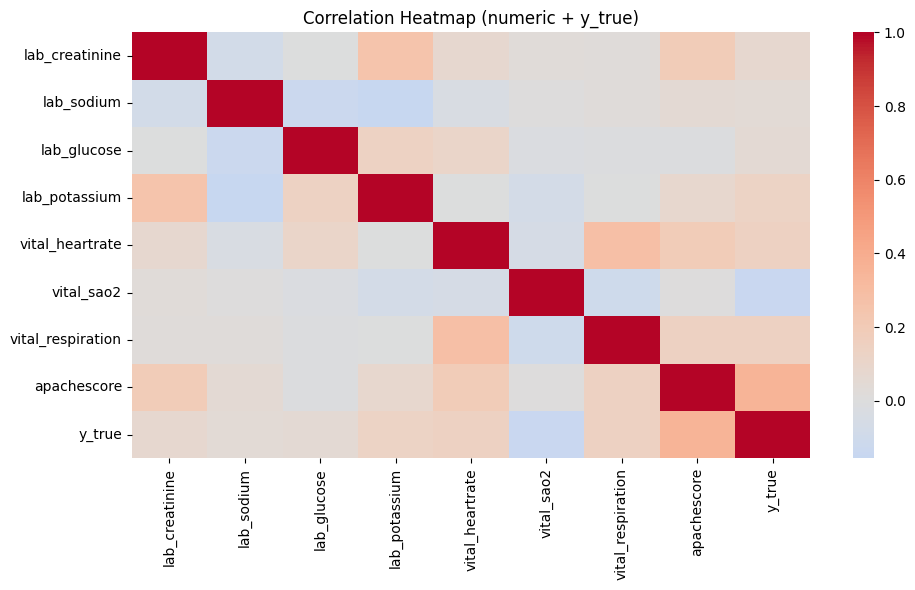

In [14]:
if len(numeric_cols) >= 2:
  plt.figure(figsize=(10, 6))
  corr = df[numeric_cols + ["y_true"]].corr(numeric_only=True)
  sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
  plt.title("Correlation Heatmap (numeric + y_true)")
  plt.tight_layout()
  plt.show()

Using: runs\canonical_dataset.csv
Shape: (2520, 17)


,patientunitstayid,hospitalid,y_true,ethnicity,gender,age_group,insurance,language,region,lab_creatinine,lab_sodium,lab_glucose,lab_potassium,vital_heartrate,vital_sao2,vital_respiration,apachescore
0,141764,59,0,Caucasian,Female,over_65,Unknown,Unknown,Midwest,NaN,NaN,NaN,NaN,104.0,NaN,NaN,NaN
1,141765,59,0,Caucasian,Female,over_65,Unknown,Unknown,Midwest,1.040,139.0,79.0,4.10,86.0,97.0,24.0,47.0
2,143870,68,0,Caucasian,Male,over_65,Unknown,Unknown,Midwest,1.015,136.0,131.5,4.40,46.0,96.0,67.0,60.0
3,144815,56,0,Caucasian,Female,under_45,Unknown,Unknown,Midwest,0.690,141.0,90.5,3.75,82.0,99.0,17.0,25.0
4,145427,68,0,Caucasian,Male,45_65,Unknown,Unknown,Midwest,1.120,139.5,128.5,4.35,64.0,96.0,16.0,37.0



Dtypes:


,patientunitstayid,hospitalid,y_true,ethnicity,gender,age_group,insurance,language,region,lab_creatinine,lab_sodium,lab_glucose,lab_potassium,vital_heartrate,vital_sao2,vital_respiration,apachescore
dtype,int64,int64,int64,str,str,str,str,str,str,float64,float64,float64,float64,float64,float64,float64,float64



Missingness (%):


...

,count
insurance,
Unknown,2520



=== language distribution ===


,count
language,
Unknown,2520



Numeric modeling columns:
['lab_creatinine', 'lab_sodium', 'lab_glucose', 'lab_potassium', 'vital_heartrate', 'vital_sao2', 'vital_respiration', 'apachescore']

Summary stats:


,count,mean,std,min,25%,50%,75%,max
lab_creatinine,2373.0,1.347679,1.345286,0.2,0.74,0.97,1.34,13.63
lab_sodium,2369.0,138.329358,4.511858,108.0,136.00,138.50,141.00,178.00
lab_glucose,2353.0,138.213132,63.362184,51.0,102.50,119.50,151.00,896.00
lab_potassium,2341.0,4.023778,0.484778,2.0,3.70,4.00,4.25,7.20
vital_heartrate,2364.0,83.136844,16.300480,6.0,71.00,82.00,94.00,151.00
vital_sao2,2330.0,96.664378,3.448327,0.0,95.00,97.00,98.00,100.00
vital_respiration,2162.0,19.331175,4.796598,0.0,16.00,19.00,22.00,67.00
apachescore,1838.0,51.956474,25.253063,-1.0,35.25,48.00,65.00,185.00


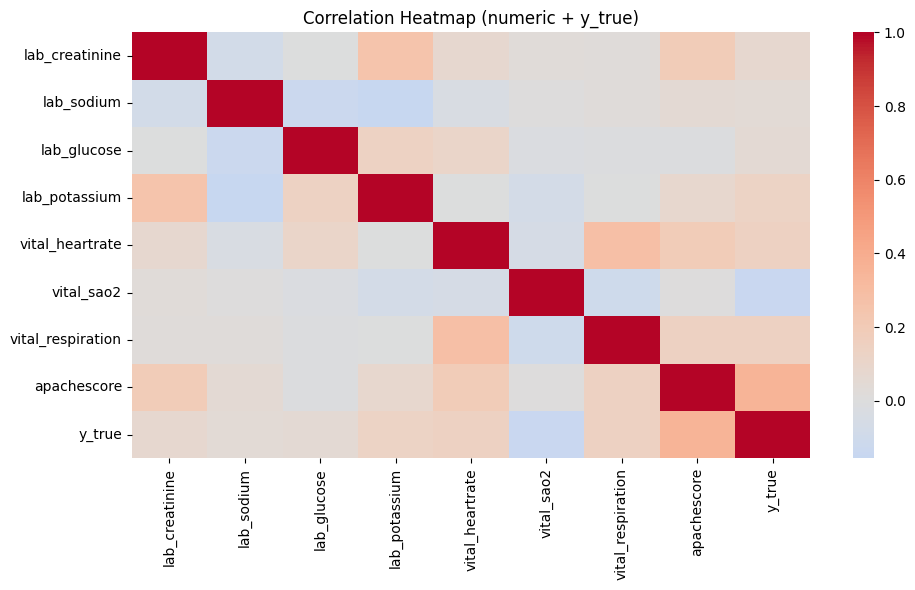


=== Mortality by ethnicity (descriptive) ===


,n,mortality_rate
group,,
Caucasian,2010,0.0861
African American,231,0.0390
Hispanic,115,0.0957
Other/Unknown,83,0.1325
Unknown,39,0.1026
Asian,30,0.1333



=== Mortality by gender (descriptive) ===


,n,mortality_rate
group,,
Male,1508,0.0822
Female,1008,0.0863



=== Mortality by age_group (descriptive) ===


,n,mortality_rate
group,,
over_65,1295,0.1174
45_65,787,0.0661
under_45,434,0.0161



=== Mortality by region (descriptive) ===


,n,mortality_rate
group,,
Midwest,807,0.0719
South,738,0.0854
West,606,0.0825
Unknown,210,0.1048
Northeast,159,0.1195


In [17]:
# =========================================================
# FairnessOps - Canonical Dataset EDA (Colab-ready)
# =========================================================
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

# ----------------------------
# 1) Locate canonical dataset
# ----------------------------

# Option A: if already in /content
# DATA_PATH = Path("/content/canonical_dataset.csv")

# Option B: if in Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = Path("/content/drive/MyDrive/Fairness Ops/runs/canonical_dataset.csv")

# Auto-candidates (edit if needed)
candidates = [
    Path("./runs/canonical_dataset.csv"),
    Path("/content/runs/canonical_dataset.csv"),
    Path("/content/drive/MyDrive/Fairness Ops/runs/canonical_dataset.csv"),
    Path("/content/drive/MyDrive/canonical_dataset.csv"),
]

DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "canonical_dataset.csv not found. Update DATA_PATH to your actual file location."
    )

print("Using:", DATA_PATH)

# ----------------------------
# 2) Load dataset
# ----------------------------

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head(5))

# ----------------------------
# 3) Basic schema + missingness
# ----------------------------

print("\nDtypes:")
display(df.dtypes.to_frame("dtype").T)
missing_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
print("\nMissingness (%):")
display(missing_pct.to_frame("missing_pct"))

# ----------------------------
# 4) Label distribution
# ----------------------------

if "y_true" not in df.columns:
    raise ValueError("Expected column 'y_true' not found.")

label_counts = df["y_true"].value_counts(dropna=False).sort_index()
label_pct = (
    (df["y_true"].value_counts(normalize=True, dropna=False) * 100)
    .sort_index()
    .round(2)
)

print("\nLabel counts:")
display(label_counts.to_frame("count"))
print("Label percent:")
display(label_pct.to_frame("pct"))
print(f"Mortality prevalence (y_true=1): {df['y_true'].mean():.3%}")

# ----------------------------
# 5) Protected attribute profiling
# ----------------------------

protected_cols = [
    c
    for c in ["ethnicity", "gender", "age_group", "region", "insurance", "language"]
    if c in df.columns
]

for c in protected_cols:
    print(f"\n=== {c} distribution ===")
    vc = df[c].fillna("Unknown").value_counts(dropna=False)
    display(vc.to_frame("count").head(20))

# ----------------------------
# 6) Numeric feature summary
# ----------------------------

id_and_label = {"patientunitstayid", "hospitalid", "y_true"}
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in id_and_label]

print("\nNumeric modeling columns:")
print(numeric_cols)

if numeric_cols:
    print("\nSummary stats:")
    display(df[numeric_cols].describe().T)

# ----------------------------
# 7) Correlation quick look
# ----------------------------

if len(numeric_cols) >= 2:
    plt.figure(figsize=(10, 6))
    corr = df[numeric_cols + ["y_true"]].corr(numeric_only=True)
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
    plt.title("Correlation Heatmap (numeric + y_true)")
    plt.tight_layout()
    plt.show()

# ----------------------------
# 8) Group mortality (descriptive)
# ----------------------------


def mortality_by_group(data, group_col, min_n=20):
    tmp = (
        data.assign(group=data[group_col].astype("object").fillna("Unknown"))
        .groupby("group")
        .agg(n=("y_true", "size"), mortality_rate=("y_true", "mean"))
        .sort_values("n", ascending=False)
    )
    tmp["mortality_rate"] = tmp["mortality_rate"].round(4)
    return tmp[tmp["n"] >= min_n]


for c in [x for x in ["ethnicity", "gender", "age_group", "region"] if x in df.columns]:
    print(f"\n=== Mortality by {c} (descriptive) ===")
    display(mortality_by_group(df, c, min_n=20).head(20))

In [18]:
print(df)

      patientunitstayid  hospitalid  y_true         ethnicity  gender age_group insurance language   region  lab_creatinine  lab_sodium  lab_glucose  \
0                141764          59       0         Caucasian  Female   over_65   Unknown  Unknown  Midwest             NaN         NaN          NaN   
1                141765          59       0         Caucasian  Female   over_65   Unknown  Unknown  Midwest           1.040       139.0         79.0   
2                143870          68       0         Caucasian    Male   over_65   Unknown  Unknown  Midwest           1.015       136.0        131.5   
3                144815          56       0         Caucasian  Female  under_45   Unknown  Unknown  Midwest           0.690       141.0         90.5   
4                145427          68       0         Caucasian    Male     45_65   Unknown  Unknown  Midwest           1.120       139.5        128.5   
...                 ...         ...     ...               ...     ...       ...       ..

In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
  roc_auc_score, average_precision_score,
  confusion_matrix, classification_report
)

In [21]:
DATA_PATH = Path("/content/canonical_dataset.csv")
df = pd.read_csv("./runs/canonical_dataset.csv")
print("Loaded:", "./runs/canonical_dataset.csv")
print("Shape:", df.shape)

Loaded: ./runs/canonical_dataset.csv
Shape: (2520, 17)


In [22]:
# 2) Define target, model features, fairness attrs
label_col = "y_true"
model_feature_cols = [
  "lab_creatinine", "lab_sodium", "lab_glucose", "lab_potassium",
  "vital_heartrate", "vital_sao2", "vital_respiration", "apachescore"
]
# Use only available + meaningful fairness attrs
fairness_cols = [c for c in ["ethnicity", "gender", "age_group", "region"] if c in df.columns]
# Optional: hard-drop attrs that are constant Unknown in your build
df = df.drop(columns=["insurance", "language"], errors="ignore")

In [23]:
# Keep only required cols
required_cols = ["patientunitstayid", "hospitalid", label_col] + fairness_cols + model_feature_cols
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
  raise ValueError(f"Missing required columns: {missing_required}")
work = df[required_cols].copy()

In [24]:
# Ensure label is valid binary
work = work.dropna(subset=[label_col]).copy()
work[label_col] = work[label_col].astype(int)
# Fill fairness attrs with Unknown for safe grouping
for c in fairness_cols:
  work[c] = work[c].astype("object").fillna("Unknown")
X = work[model_feature_cols].copy()
y = work[label_col].copy()


In [25]:
print(model_feature_cols)

['lab_creatinine', 'lab_sodium', 'lab_glucose', 'lab_potassium', 'vital_heartrate', 'vital_sao2', 'vital_respiration', 'apachescore']


In [26]:
print(label_col)

y_true


In [27]:
# 3) Train/test split (stratified), preserve index for fairness slicing
X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(
  X, y, work.index,
  test_size=0.25,
  random_state=42,
  stratify=y
)

In [28]:
# 4) Build + fit model
logreg_pipe = Pipeline([
  ("imputer", SimpleImputer(strategy="median")),
  ("model", LogisticRegression(
      max_iter=1000,
      class_weight="balanced",
      solver="liblinear",
      random_state=42
  ))
])

In [29]:
logreg_pipe.fit(X_tr, y_tr)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

In [30]:
# 5) Predictions
proba_te = logreg_pipe.predict_proba(X_te)[:, 1]
pred_te_05 = (proba_te >= 0.50).astype(int)

In [31]:
# 6) Overall performance
roc = roc_auc_score(y_te, proba_te)
pr = average_precision_score(y_te, proba_te)
cm = confusion_matrix(y_te, pred_te_05)

In [32]:
print("\n=== Logistic Regression Overall Metrics ===")
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC : {pr:.4f}")
print("\nConfusion Matrix @0.50:")
print(cm)
print("\nClassification Report @0.50:")
print(classification_report(y_te, pred_te_05, digits=4))


=== Logistic Regression Overall Metrics ===
ROC-AUC: 0.8363
PR-AUC : 0.5018

Confusion Matrix @0.50:
[[444 133]
 [ 14  39]]

Classification Report @0.50:
              precision    recall  f1-score   support

           0     0.9694    0.7695    0.8580       577
           1     0.2267    0.7358    0.3467        53

    accuracy                         0.7667       630
   macro avg     0.5981    0.7527    0.6023       630
weighted avg     0.9070    0.7667    0.8150       630



In [33]:
# 7) Build fairness-ready prediction frame
pred_df = work.loc[idx_te, ["patientunitstayid", "hospitalid", label_col] + fairness_cols].copy()
pred_df["y_pred_proba"] = proba_te
pred_df["y_pred_label_05"] = pred_te_05
print("\nFairness-ready prediction frame:")
display(pred_df.head())


Fairness-ready prediction frame:


,patientunitstayid,hospitalid,y_true,ethnicity,gender,age_group,region,y_pred_proba,y_pred_label_05
1924,2726655,407,0,Hispanic,Male,under_45,West,0.067695,0
1854,2677807,387,0,Caucasian,Male,over_65,West,0.365565,0
1229,1569571,249,0,Caucasian,Female,over_65,Midwest,0.275140,0
609,752830,165,0,African American,Female,45_65,West,0.122211,0
135,214519,66,0,Caucasian,Female,45_65,Midwest,0.187792,0


In [34]:
# Pick threshold: using 0.40 for safety-first recall
chosen_threshold = 0.40
y_pred_label_chosen = (proba_te >= chosen_threshold).astype(int)

# Recreate pred_df with the chosen threshold
pred_df_final = work.loc[idx_te, ["patientunitstayid", label_col] + fairness_cols].copy()
pred_df_final["y_pred_proba"] = proba_te
pred_df_final["y_pred_label"] = y_pred_label_chosen

print("Fairness-ready prediction frame with chosen threshold:")
display(pred_df_final.head())

Fairness-ready prediction frame with chosen threshold:


,patientunitstayid,y_true,ethnicity,gender,age_group,region,y_pred_proba,y_pred_label
1924,2726655,0,Hispanic,Male,under_45,West,0.067695,0
1854,2677807,0,Caucasian,Male,over_65,West,0.365565,0
1229,1569571,0,Caucasian,Female,over_65,Midwest,0.275140,0
609,752830,0,African American,Female,45_65,West,0.122211,0
135,214519,0,Caucasian,Female,45_65,Midwest,0.187792,0


In [35]:
import json

# Freeze metadata
metadata = {
    "model_type": "Logistic Regression",
    "features": model_feature_cols,
    "target_label": label_col,
    "protected_attributes": fairness_cols,
    "training_test_split_ratio": 0.25,
    "training_test_split_random_state": 42,
    "prediction_threshold": chosen_threshold
}

print("Metadata created:")
display(metadata)

Metadata created:


{'model_type': 'Logistic Regression',
 'features': ['lab_creatinine',
  'lab_sodium',
  'lab_glucose',
  'lab_potassium',
  'vital_heartrate',
  'vital_sao2',
  'vital_respiration',
  'apachescore'],
 'target_label': 'y_true',
 'protected_attributes': ['ethnicity', 'gender', 'age_group', 'region'],
 'training_test_split_ratio': 0.25,
 'training_test_split_random_state': 42,
 'prediction_threshold': 0.4}

In [36]:
for t in [0.30, 0.40, 0.50, 0.60]:
    p = (proba_te >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, p).ravel()
    recall    = tp / (tp + fn) if (tp + fn) else np.nan
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    print(f"thr={t:.2f} | precision={precision:.3f} recall={recall:.3f} | tp={tp} fp={fp} fn={fn} tn={tn}")

thr=0.30 | precision=0.126 recall=0.943 | tp=50 fp=347 fn=3 tn=230
thr=0.40 | precision=0.167 recall=0.849 | tp=45 fp=225 fn=8 tn=352
thr=0.50 | precision=0.227 recall=0.736 | tp=39 fp=133 fn=14 tn=444
thr=0.60 | precision=0.307 recall=0.585 | tp=31 fp=70 fn=22 tn=507


## Fairness Pipeline (Print + Export)

This section computes the 4 MVP fairness dimensions from model predictions and exports results.

Exports are written to:
- `runs/fairness_outputs/`

Expected input in memory (from previous model cells):
- `pred_df_final` (preferred) OR `pred_df`
- columns: `y_true`, `y_pred_proba`, `ethnicity`, `gender`, `age_group`, `region`

In [41]:
from pathlib import Path
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.metrics import roc_auc_score

# ---------- Resolve prediction frame ----------
if 'pred_df_final' in globals():
    fairness_df = pred_df_final.copy()
elif 'pred_df' in globals():
    fairness_df = pred_df.copy()
else:
    raise RuntimeError("Need pred_df_final or pred_df in memory. Run model/prediction cells first.")

required_cols = ['y_true', 'y_pred_proba', 'ethnicity', 'gender', 'age_group', 'region']
missing_cols = [c for c in required_cols if c not in fairness_df.columns]
if missing_cols:
    raise ValueError(f"Prediction frame missing required columns: {missing_cols}")

for c in ['ethnicity', 'gender', 'age_group', 'region']:
    fairness_df[c] = fairness_df[c].astype('object').fillna('Unknown')

fairness_df['y_true'] = fairness_df['y_true'].astype(int)
fairness_df['y_pred_proba'] = fairness_df['y_pred_proba'].astype(float)

# ---------- Output folder ----------
OUT_DIR = Path('runs') / 'fairness_outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('Fairness input shape:', fairness_df.shape)
print('Output folder:', OUT_DIR.resolve())

Fairness input shape: (630, 8)
Output folder: C:\Users\venka\Desktop\Fairness Ops\runs\fairness_outputs


In [40]:
from pathlib import Path
out = Path(r"c:\Users\venka\Desktop\Fairness Ops\runs\fairness_outputs")
print("exists:", out.exists())
print("files:", [p.name for p in out.glob("*.csv")])

exists: True
files: []


In [43]:
# =============================
# 1) Demographic Fairness
# =============================
attrs = ['ethnicity', 'gender', 'age_group', 'region']
min_group_n = 30

fairness_group_rows = []
fairness_attr_rows = []
overall_auc = roc_auc_score(fairness_df['y_true'], fairness_df['y_pred_proba'])

for attr in attrs:
    auc_map = {}
    counts = fairness_df[attr].value_counts(dropna=False)

    for group, n in counts.items():
        m = fairness_df[attr] == group
        yt = fairness_df.loc[m, 'y_true'].values
        yp = fairness_df.loc[m, 'y_pred_proba'].values

        if n >= min_group_n and len(np.unique(yt)) >= 2:
            auc_g = roc_auc_score(yt, yp)
            auc_map[group] = auc_g
            fairness_group_rows.append({'attribute': attr, 'group': group, 'n': int(n), 'auc': float(auc_g)})
        else:
            fairness_group_rows.append({'attribute': attr, 'group': group, 'n': int(n), 'auc': np.nan})

    valid_aucs = [v for v in auc_map.values() if pd.notna(v)]
    gap = (max(valid_aucs) - min(valid_aucs)) if len(valid_aucs) >= 2 else np.nan

    severity = (
        'RED' if pd.notna(gap) and gap > 0.20 else
        'YELLOW' if pd.notna(gap) and gap > 0.10 else
        'GREEN' if pd.notna(gap) else
        'INSUFFICIENT_DATA'
    )

    fairness_attr_rows.append({
        'attribute': attr,
        'overall_auc': float(overall_auc),
        'max_auc_gap': float(gap) if pd.notna(gap) else np.nan,
        'severity': severity,
        'valid_group_aucs': len(valid_aucs)
    })

fairness_by_group = pd.DataFrame(fairness_group_rows).sort_values(['attribute', 'group'])
fairness_by_attribute = pd.DataFrame(fairness_attr_rows).sort_values('max_auc_gap', ascending=False)

print('=== Demographic Fairness (attribute-level) ===')
display(fairness_by_attribute)

# =============================
# 2) Representation
# =============================
rep_rows = []
for attr in attrs:
    for group, sub in fairness_df.groupby(attr):
        n = len(sub)
        p_pos = sub['y_true'].mean()
        n_eff = n * 2 * min(p_pos, 1 - p_pos)
        status = (
            'reliable' if n_eff >= 30 else
            'low_confidence' if n_eff >= 10 else
            'suppressed'
        )
        rep_rows.append({
            'attribute': attr,
            'group': group,
            'n': int(n),
            'positive_rate': float(p_pos),
            'n_eff': float(n_eff),
            'status': status
        })

representation = pd.DataFrame(rep_rows).sort_values(['attribute', 'n'], ascending=[True, False])
print('=== Representation (top rows) ===')
display(representation.head(20))

# =============================
# 3) Intersectionality (2-way)
# =============================
inter_rows = []
min_inter_n = 20

for a1, a2 in combinations(attrs, 2):
    for (g1, g2), sub in fairness_df.groupby([a1, a2]):
        n = len(sub)
        if n < min_inter_n:
            continue

        yt = sub['y_true'].values
        yp = sub['y_pred_proba'].values
        if len(np.unique(yt)) < 2:
            continue

        auc_sub = roc_auc_score(yt, yp)
        gap = overall_auc - auc_sub
        p_pos = yt.mean()
        n_eff = n * 2 * min(p_pos, 1 - p_pos)
        score = gap * np.sqrt(max(n_eff, 1))

        inter_rows.append({
            'attr1': a1, 'group1': g1,
            'attr2': a2, 'group2': g2,
            'n': int(n),
            'n_eff': float(n_eff),
            'auc_subgroup': float(auc_sub),
            'auc_overall': float(overall_auc),
            'gap_vs_overall': float(gap),
            'score': float(score)
        })

intersectionality_all = pd.DataFrame(inter_rows).sort_values('score', ascending=False)
intersectionality_top = intersectionality_all.head(25)
print('=== Intersectionality (top 10) ===')
display(intersectionality_top.head(10))

# =============================
# 4) Fairness Drift (windowed demo)
# =============================
n_windows = 6
tmp = fairness_df.sample(frac=1, random_state=42).reset_index(drop=True)
tmp['window_id'] = pd.cut(tmp.index, bins=n_windows, labels=False, include_lowest=True)

drift_rows = []
for attr in attrs:
    for w, subw in tmp.groupby('window_id'):
        aucs = []
        for _, subg in subw.groupby(attr):
            if len(subg) < 20 or len(subg['y_true'].unique()) < 2:
                continue
            aucs.append(roc_auc_score(subg['y_true'], subg['y_pred_proba']))

        gap_w = (max(aucs) - min(aucs)) if len(aucs) >= 2 else np.nan
        drift_rows.append({'attribute': attr, 'window_id': int(w), 'gap': gap_w})

fairness_drift = pd.DataFrame(drift_rows)

drift_summary_rows = []
for attr, sub in fairness_drift.groupby('attribute'):
    s = sub.dropna(subset=['gap']).sort_values('window_id')
    slope = np.polyfit(s['window_id'], s['gap'], 1)[0] if len(s) >= 2 else np.nan
    alert = (
        'RED' if pd.notna(slope) and slope > 0.02 else
        'YELLOW' if pd.notna(slope) and slope > 0.005 else
        'GREEN' if pd.notna(slope) else
        'INSUFFICIENT_DATA'
    )
    drift_summary_rows.append({'attribute': attr, 'gap_trend_slope': slope, 'drift_alert': alert})

fairness_drift_summary = pd.DataFrame(drift_summary_rows)
print('=== Fairness Drift Summary ===')
display(fairness_drift_summary)

# =============================
# Export all outputs
# =============================
fairness_by_attribute.to_csv(OUT_DIR / 'fairness_by_attribute.csv', index=False)
fairness_by_group.to_csv(OUT_DIR / 'fairness_by_group.csv', index=False)
representation.to_csv(OUT_DIR / 'representation.csv', index=False)
intersectionality_all.to_csv(OUT_DIR / 'intersectionality_all.csv', index=False)
intersectionality_top.to_csv(OUT_DIR / 'intersectionality_top.csv', index=False)
fairness_drift.to_csv(OUT_DIR / 'fairness_drift.csv', index=False)
fairness_drift_summary.to_csv(OUT_DIR / 'fairness_drift_summary.csv', index=False)

summary = pd.DataFrame({
    'dimension': [
        'Demographic Fairness',
        'Representation',
        'Intersectionality (2-way)',
        'Fairness Drift'
    ],
    'key_output_file': [
        'fairness_by_attribute.csv',
        'representation.csv',
        'intersectionality_top.csv',
        'fairness_drift_summary.csv'
    ],
    'headline_signal': [
        f"Max attribute gap: {fairness_by_attribute['max_auc_gap'].max():.3f}" if len(fairness_by_attribute) else 'N/A',
        f"Suppressed groups: {(representation['status'] == 'suppressed').sum()}",
        f"Top intersectional rows: {len(intersectionality_top)}",
        f"Drift alerts: {', '.join(sorted(fairness_drift_summary['drift_alert'].unique())) if len(fairness_drift_summary) else 'N/A'}"
    ]
})
summary.to_csv(OUT_DIR / 'dimension_summary.csv', index=False)

print('\n=== Export complete ===')
for p in sorted(OUT_DIR.glob('*.csv')):
    print('-', p.name)

display(summary)

=== Demographic Fairness (attribute-level) ===


,attribute,overall_auc,max_auc_gap,severity,valid_group_aucs
0,ethnicity,0.836271,0.282273,RED,2
2,age_group,0.836271,0.232780,RED,3
3,region,0.836271,0.125898,YELLOW,5
1,gender,0.836271,0.014572,GREEN,2


=== Representation (top rows) ===


,attribute,group,n,positive_rate,n_eff,status
11,age_group,over_65,300,0.106667,64.0,reliable
9,age_group,45_65,209,0.090909,38.0,reliable
12,age_group,under_45,120,0.016667,4.0,suppressed
10,age_group,Unknown,1,0.000000,0.0,suppressed
2,ethnicity,Caucasian,506,0.083004,84.0,reliable
0,ethnicity,African American,61,0.032787,4.0,suppressed
3,ethnicity,Hispanic,29,0.068966,4.0,suppressed
5,ethnicity,Other/Unknown,18,0.222222,8.0,suppressed
4,ethnicity,Native American,7,0.000000,0.0,suppressed
1,ethnicity,Asian,5,0.600000,4.0,suppressed


=== Intersectionality (top 10) ===


,attr1,group1,attr2,group2,n,n_eff,auc_subgroup,auc_overall,gap_vs_overall,score
32,age_group,over_65,region,Midwest,87,16.0,0.596519,0.836271,0.239752,0.959008
14,gender,Female,age_group,over_65,115,16.0,0.653037,0.836271,0.183234,0.732934
6,ethnicity,Caucasian,age_group,over_65,256,52.0,0.750167,0.836271,0.086104,0.620902
20,gender,Female,region,Northeast,21,2.0,0.400000,0.836271,0.436271,0.616980
0,ethnicity,African American,gender,Male,36,4.0,0.529412,0.836271,0.306859,0.613718
7,ethnicity,African American,region,South,39,4.0,0.554054,0.836271,0.282217,0.564434
4,ethnicity,African American,age_group,45_65,30,4.0,0.589286,0.836271,0.246985,0.493970
19,gender,Female,region,Midwest,73,6.0,0.657143,0.836271,0.179128,0.438772
36,age_group,over_65,region,West,87,26.0,0.752599,0.836271,0.083672,0.426646
17,gender,Male,age_group,over_65,185,48.0,0.793737,0.836271,0.042534,0.294683


=== Fairness Drift Summary ===


,attribute,gap_trend_slope,drift_alert
0,age_group,-0.039502,GREEN
1,ethnicity,NaN,INSUFFICIENT_DATA
2,gender,0.105479,RED
3,region,0.042970,RED



=== Export complete ===
- dimension_summary.csv
- fairness_by_attribute.csv
- fairness_by_group.csv
- fairness_drift.csv
- fairness_drift_summary.csv
- intersectionality_all.csv
- intersectionality_top.csv
- representation.csv


,dimension,key_output_file,headline_signal
0,Demographic Fairness,fairness_by_attribute.csv,Max attribute gap: 0.282
1,Representation,representation.csv,Suppressed groups: 10
2,Intersectionality (2-way),intersectionality_top.csv,Top intersectional rows: 25
3,Fairness Drift,fairness_drift_summary.csv,"Drift alerts: GREEN, INSUFFICIENT_DATA, RED"
